In [ ]:
from pathlib import Path
from src.peak_fitting import find_and_fit_peaks, plot_multi_peak_fit
from src.ras_loader import load_ras_file

ras_path = Path(
    r"data\XRD_profiles\XRD\250915_XRD_PB_ID_43_44\ID44_PB_基板加熱100度_高真空_2000W.ras"
)

ras_df = load_ras_file(ras_path)


# CIFファイルからの理論XRDパターン生成

CIFファイルから結晶構造情報を読み込み、Cu Kα線での理論的なピーク位置と強度を計算します。

CIFファイルを読み込み中: 1538066.cif
結晶系: 229
格子定数: a=3.2780 Å
波長: 1.5406 Å (CuKa1)
理論XRDパターンを計算中...
理論XRDパターンを計算中...
検出されたピーク数: 8
検出されたピーク数: 8
2θ範囲: 38.81 - 83.56°

=== 理論ピーク（相対強度 > 1%） ===
shape: (8, 3)
┌───────────┬────────────────────┬───────────┐
│ two_theta ┆ relative_intensity ┆ d_spacing │
│ ---       ┆ ---                ┆ ---       │
│ f64       ┆ f64                ┆ f64       │
╞═══════════╪════════════════════╪═══════════╡
│ 38.813602 ┆ 100.0              ┆ 2.318263  │
│ 38.913614 ┆ 50.614397          ┆ 2.312535  │
│ 56.065758 ┆ 14.994248          ┆ 1.639005  │
│ 56.215777 ┆ 7.673051           ┆ 1.634986  │
│ 70.277535 ┆ 28.289477          ┆ 1.338346  │
│ 70.47756  ┆ 14.245781          ┆ 1.335037  │
│ 83.309164 ┆ 8.379152           ┆ 1.158971  │
│ 83.559195 ┆ 4.192177           ┆ 1.156138  │
└───────────┴────────────────────┴───────────┘
検出されたピーク数: 8
検出されたピーク数: 8
2θ範囲: 38.81 - 83.56°

=== 理論ピーク（相対強度 > 1%） ===
shape: (8, 3)
┌───────────┬────────────────────┬───────────┐
│ two_theta ┆

# Whole Powder Pattern Fitting (WPPF)

CIFファイルから得られた理論ピーク位置を使って実験データをフィッティングします。
2つの方法を提供：
1. **強度比制約あり**: 理論強度比を参照して各ピークの相対強度を制約
2. **強度比自由**: ピーク位置のみ制約、強度は自由パラメータ

In [19]:
import matplotlib.pyplot as plt
import polars as pl


def wppf_constrained_intensity(
    x,
    y,
    theoretical_peaks_df,
    model_class,
    background_type="spline",
    poly_degree=2,
    num_knots=10,
    intensity_ratio_weight=1.0,
    peak_position_tolerance=0.5,
):
    """
    Whole Powder Pattern Fitting with constrained intensity ratios
    理論強度比を参照して各ピークの相対強度を制約

    Parameters
    ----------
    x : array_like
        実験データのx軸（2θ）
    y : array_like
        実験データの強度
    theoretical_peaks_df : polars.DataFrame
        理論ピーク情報（two_theta, relative_intensity列が必要）
    model_class : class
        使用するピークモデル (GaussianModel, PseudoVoigtModel等)
    background_type : str, optional
        バックグラウンドモデル ('spline', 'polynomial', 'linear')
    poly_degree : int, optional
        多項式次数（polynomial使用時）
    num_knots : int, optional
        B-splineノット数（spline使用時）
    intensity_ratio_weight : float, optional
        強度比制約の重み（0-1、1が最も強い制約）
    peak_position_tolerance : float, optional
        ピーク位置の許容変動範囲（度）

    Returns
    -------
    result : ModelResult
        フィッティング結果
    """
    print("=== WPPF with Constrained Intensity Ratios ===")
    print(f"理論ピーク数: {len(theoretical_peaks_df)}")

    # バックグラウンドモデルを作成
    if background_type == "spline":
        knot_positions = np.linspace(x.min(), x.max(), num_knots + 2)[1:-1]
        background_model = SplineModel(prefix="bg_", xknots=knot_positions)
        params = background_model.guess(y, x=x)
    elif background_type == "polynomial":
        background_model = PolynomialModel(degree=poly_degree, prefix="bg_")
        params = background_model.guess(y, x=x)
    else:
        background_model = LinearModel(prefix="bg_")
        params = background_model.make_params()
        params["bg_slope"].set(value=0)
        params["bg_intercept"].set(value=y.min())

    composite_model = background_model

    # 理論ピークの最大強度を取得（正規化用）
    max_theoretical_intensity = theoretical_peaks_df["relative_intensity"].max()

    # 全体のスケールファクターを導入
    scale_factor_guess = (y.max() - y.min()) / max_theoretical_intensity

    # 各理論ピークに対してモデルを構築
    for i, row in enumerate(theoretical_peaks_df.iter_rows(named=True)):
        peak_model = model_class(prefix=f"p{i}_")
        composite_model += peak_model

        center = row["two_theta"]
        relative_intensity = row["relative_intensity"]

        # 強度比に基づいて振幅を計算（スケールファクター適用）
        amplitude = (
            scale_factor_guess
            * relative_intensity
            / max_theoretical_intensity
            * (y.max() - y.min())
        )

        # 初期FWHMを推定
        fwhm_guess = 0.2  # 度単位の初期推定値
        sigma = fwhm_guess / 2.355

        params.update(peak_model.make_params())

        # 振幅を制約（理論強度比に基づく）
        if intensity_ratio_weight > 0:
            # 強度比を維持しつつ、若干の変動を許容
            amp_min = amplitude * (1 - 0.5 * intensity_ratio_weight)
            amp_max = amplitude * (1 + 0.5 * intensity_ratio_weight)
            params[f"p{i}_amplitude"].set(
                value=amplitude, min=max(amp_min, 0), max=amp_max
            )
        else:
            # 制約なし
            params[f"p{i}_amplitude"].set(value=amplitude, min=0)

        # ピーク位置を制約（格子定数変動を考慮）
        params[f"p{i}_center"].set(
            value=center,
            min=center - peak_position_tolerance,
            max=center + peak_position_tolerance,
        )

        # ピーク幅
        params[f"p{i}_sigma"].set(value=sigma, min=0.01, max=1.0)

        # モデル固有のパラメータ
        if "fraction" in peak_model.param_names:
            params[f"p{i}_fraction"].set(value=0.5, min=0, max=1)

    print(f"構築されたピークモデル数: {i + 1}")
    print(f"バックグラウンドタイプ: {background_type}")

    # フィッティング実行
    print("\n=== フィッティング開始 ===")
    result = composite_model.fit(y, params, x=x, nan_policy="omit", max_nfev=10000)

    print(f"フィッティング成功: {result.success}")
    if not result.success:
        print(f"警告: {result.message}")

    return result


def wppf_free_intensity(
    x,
    y,
    theoretical_peaks_df,
    model_class,
    background_type="spline",
    poly_degree=2,
    num_knots=10,
    peak_position_tolerance=0.5,
):
    """
    Whole Powder Pattern Fitting with free intensity
    ピーク位置のみ制約、強度は自由パラメータ

    Parameters
    ----------
    x : array_like
        実験データのx軸（2θ）
    y : array_like
        実験データの強度
    theoretical_peaks_df : polars.DataFrame
        理論ピーク情報（two_theta列が必要）
    model_class : class
        使用するピークモデル (GaussianModel, PseudoVoigtModel等)
    background_type : str, optional
        バックグラウンドモデル ('spline', 'polynomial', 'linear')
    poly_degree : int, optional
        多項式次数（polynomial使用時）
    num_knots : int, optional
        B-splineノット数（spline使用時）
    peak_position_tolerance : float, optional
        ピーク位置の許容変動範囲（度）

    Returns
    -------
    result : ModelResult
        フィッティング結果
    """
    print("=== WPPF with Free Intensity ===")
    print(f"理論ピーク数: {len(theoretical_peaks_df)}")

    # バックグラウンドモデルを作成
    if background_type == "spline":
        knot_positions = np.linspace(x.min(), x.max(), num_knots + 2)[1:-1]
        background_model = SplineModel(prefix="bg_", xknots=knot_positions)
        params = background_model.guess(y, x=x)
    elif background_type == "polynomial":
        background_model = PolynomialModel(degree=poly_degree, prefix="bg_")
        params = background_model.guess(y, x=x)
    else:
        background_model = LinearModel(prefix="bg_")
        params = background_model.make_params()
        params["bg_slope"].set(value=0)
        params["bg_intercept"].set(value=y.min())

    composite_model = background_model

    # 各理論ピークに対してモデルを構築
    for i, row in enumerate(theoretical_peaks_df.iter_rows(named=True)):
        peak_model = model_class(prefix=f"p{i}_")
        composite_model += peak_model

        center = row["two_theta"]

        # 初期振幅を推定（データから）
        # centerに最も近いデータポイントの強度を使用
        idx = np.argmin(np.abs(x - center))
        amplitude_guess = max(y[idx] - y.min(), (y.max() - y.min()) * 0.1)

        # 初期FWHMを推定
        fwhm_guess = 0.2
        sigma = fwhm_guess / 2.355

        params.update(peak_model.make_params())

        # 振幅は自由（制約なし）
        params[f"p{i}_amplitude"].set(
            value=amplitude_guess, min=0, max=(y.max() - y.min()) * 5
        )

        # ピーク位置を制約
        params[f"p{i}_center"].set(
            value=center,
            min=center - peak_position_tolerance,
            max=center + peak_position_tolerance,
        )

        # ピーク幅
        params[f"p{i}_sigma"].set(value=sigma, min=0.01, max=1.0)

        # モデル固有のパラメータ
        if "fraction" in peak_model.param_names:
            params[f"p{i}_fraction"].set(value=0.5, min=0, max=1)

    print(f"構築されたピークモデル数: {i + 1}")
    print(f"バックグラウンドタイプ: {background_type}")

    # フィッティング実行
    print("\n=== フィッティング開始 ===")
    result = composite_model.fit(y, params, x=x, nan_policy="omit", max_nfev=10000)

    print(f"フィッティング成功: {result.success}")
    if not result.success:
        print(f"警告: {result.message}")

    return result


def plot_wppf_result(x, y, result, theoretical_peaks_df, method="constrained"):
    """
    WPPFフィッティング結果をプロット

    Parameters
    ----------
    x : array_like
        実験データのx軸
    y : array_like
        実験データの強度
    result : ModelResult
        フィッティング結果
    theoretical_peaks_df : polars.DataFrame
        理論ピーク情報
    method : str, optional
        フィッティング方法（'constrained' or 'free'）
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # 上段: データとフィッティング結果
    ax1.plot(x, y, "b.", label="Experimental Data", markersize=3, alpha=0.5)
    ax1.plot(x, result.best_fit, "r-", label="WPPF Fit", linewidth=2)

    # 各ピークのコンポーネントをプロット
    comps = result.eval_components(x=x)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(theoretical_peaks_df)))

    for i, (row, color) in enumerate(
        zip(theoretical_peaks_df.iter_rows(named=True), colors)
    ):
        if f"p{i}_" in comps:
            theoretical_pos = row["two_theta"]
            fitted_center = result.params[f"p{i}_center"].value
            label = f"Peak {i + 1} (theory: {theoretical_pos:.2f}°, fit: {fitted_center:.2f}°)"
            ax1.plot(x, comps[f"p{i}_"], "--", color=color, label=label, linewidth=1)

    # バックグラウンド
    if "bg_" in comps:
        ax1.plot(x, comps["bg_"], "k:", label="Background", linewidth=2)

    # 理論ピーク位置に縦線
    for row in theoretical_peaks_df.iter_rows(named=True):
        ax1.axvline(
            x=row["two_theta"],
            color="gray",
            linestyle="--",
            alpha=0.3,
            linewidth=0.8,
        )

    ax1.set_xlabel("2θ (degrees)", fontsize=12)
    ax1.set_ylabel("Intensity (cps)", fontsize=12)
    title = f"WPPF Result - {'Constrained Intensity' if method == 'constrained' else 'Free Intensity'}"
    ax1.set_title(title, fontsize=14, fontweight="bold")
    ax1.legend(loc="best", fontsize=7, ncol=2)
    ax1.grid(True, alpha=0.3)

    # 下段: 残差
    residual = y - result.best_fit
    ax2.plot(x, residual, "g-", linewidth=1)
    ax2.axhline(y=0, color="k", linestyle="--", linewidth=1)
    ax2.fill_between(x, 0, residual, alpha=0.3, color="green")
    ax2.set_xlabel("2θ (degrees)", fontsize=12)
    ax2.set_ylabel("Residual", fontsize=12)
    ax2.set_title("Fit Residuals", fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # フィッティング統計を表示
    print("\n=== Fitting Statistics ===")
    print(f"Chi-squared: {result.chisqr:.4e}")
    print(f"Reduced chi-squared: {result.redchi:.4e}")
    print(f"R-squared (R²): {result.rsquared:.6f}")
    print(f"AIC: {result.aic:.4f}")
    print(f"BIC: {result.bic:.4f}")

    # R-factorを計算
    y_obs = y
    y_calc = result.best_fit
    y_bg = comps.get("bg_", np.zeros_like(y))

    # Rp (Profile R-factor)
    rp = np.sum(np.abs(y_obs - y_calc)) / np.sum(y_obs) * 100

    # Rwp (Weighted Profile R-factor)
    weights = 1 / np.where(y_obs > 0, y_obs, 1)  # Poisson統計に基づく重み
    rwp = (
        np.sqrt(np.sum(weights * (y_obs - y_calc) ** 2) / np.sum(weights * y_obs**2))
        * 100
    )

    # RBragg (Bragg R-factor) - ピーク強度の比較
    # 各ピークの積分強度を計算
    peak_intensities_obs = []
    peak_intensities_calc = []

    for i in range(len(theoretical_peaks_df)):
        if f"p{i}_" in comps:
            peak_comp = comps[f"p{i}_"]
            # ピーク成分の積分強度
            I_calc = np.trapz(peak_comp, x)
            peak_intensities_calc.append(I_calc)

            # 観測ピーク強度（バックグラウンド除去後）
            center = result.params[f"p{i}_center"].value
            fwhm = result.params.get(
                f"p{i}_fwhm", result.params.get(f"p{i}_sigma", 0.1) * 2.355
            ).value
            mask = np.abs(x - center) < fwhm * 2
            if np.any(mask):
                I_obs = np.trapz(np.maximum(y[mask] - y_bg[mask], 0), x[mask])
                peak_intensities_obs.append(I_obs)
            else:
                peak_intensities_obs.append(0)

    if len(peak_intensities_obs) > 0:
        r_bragg = (
            np.sum(
                np.abs(np.array(peak_intensities_obs) - np.array(peak_intensities_calc))
            )
            / np.sum(peak_intensities_obs)
            * 100
        )
    else:
        r_bragg = np.nan

    print("\nR-factors:")
    print(f"  Rp:     {rp:.2f}%")
    print(f"  Rwp:    {rwp:.2f}%")
    print(f"  RBragg: {r_bragg:.2f}%")

    # ピークパラメータを表形式で表示
    print("\n=== Peak Parameters ===")
    print(
        f"{'Peak':<6} {'Theory 2θ':<12} {'Fitted 2θ':<12} {'Δ2θ':<10} {'Amplitude':<12} {'FWHM':<10}"
    )
    print("-" * 72)

    for i, row in enumerate(theoretical_peaks_df.iter_rows(named=True)):
        theory_pos = row["two_theta"]
        fitted_pos = result.params[f"p{i}_center"].value
        delta = fitted_pos - theory_pos
        amplitude = result.params[f"p{i}_amplitude"].value
        fwhm_param = result.params.get(f"p{i}_fwhm")
        if fwhm_param:
            fwhm = fwhm_param.value
        else:
            sigma = result.params.get(f"p{i}_sigma", 0.1).value
            fwhm = sigma * 2.355

        print(
            f"{i + 1:<6} {theory_pos:<12.4f} {fitted_pos:<12.4f} {delta:<10.4f} {amplitude:<12.2f} {fwhm:<10.4f}"
        )

    return result

## WPPF実行例1: 強度比制約あり

理論強度比を参照してフィッティング。各ピークの相対強度が理論値に近くなるよう制約します。

=== WPPF with Constrained Intensity Ratios ===
理論ピーク数: 8
構築されたピークモデル数: 8
バックグラウンドタイプ: spline

=== フィッティング開始 ===
フィッティング成功: False
警告: Tolerance seems to be too small. Could not estimate error-bars.
フィッティング成功: False
警告: Tolerance seems to be too small. Could not estimate error-bars.


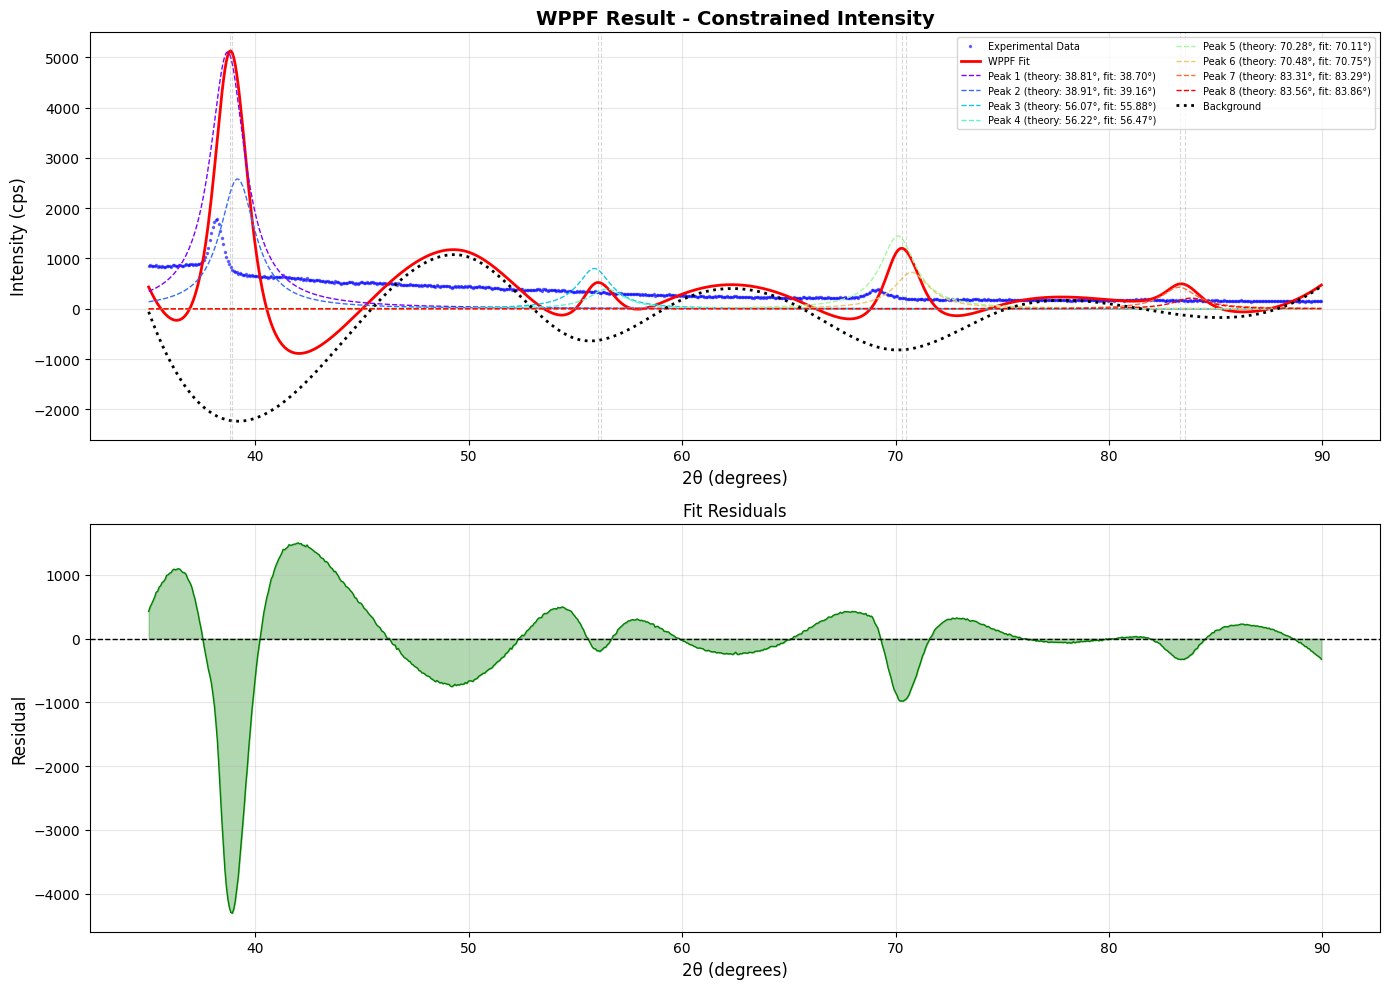


=== Fitting Statistics ===
Chi-squared: 4.3287e+08
Reduced chi-squared: 5.8181e+05
R-squared (R²): -8.122196
AIC: 10474.1210
BIC: 10670.1332

R-factors:
  Rp:     121.46%
  Rwp:    159.79%
  RBragg: 47.68%

=== Peak Parameters ===
Peak   Theory 2θ    Fitted 2θ    Δ2θ        Amplitude    FWHM      
------------------------------------------------------------------------
1      38.8136      38.6981      -0.1155    16020.67     1.9973    
2      38.9136      39.1638      0.2502     8108.77      2.0000    
3      56.0658      55.8828      -0.1829    2402.18      1.9076    
4      56.2158      56.4676      0.2518     1229.27      1.9835    
5      70.2775      70.1087      -0.1688    4532.16      1.9904    
6      70.4776      70.7534      0.2759     2282.27      1.9999    
7      83.3092      83.2859      -0.0232    1342.40      1.9948    
8      83.5592      83.8556      0.2964     671.61       1.9999    


C:\Users\sato1\AppData\Local\Temp\ipykernel_26068\2548928397.py:343: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_calc = np.trapz(peak_comp, x)
C:\Users\sato1\AppData\Local\Temp\ipykernel_26068\2548928397.py:353: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_obs = np.trapz(np.maximum(y[mask] - y_bg[mask], 0), x[mask])


In [20]:
from lmfit.models import PseudoVoigtModel

# 実験データの準備
ras_x = ras_df["x"].to_numpy()
ras_y = ras_df["cps"].to_numpy()

# CIFから理論ピークを取得（すでに実行済み）
if peaks_df is not None:
    # 強度比制約ありでWPPF実行
    result_constrained = wppf_constrained_intensity(
        ras_x,
        ras_y,
        peaks_df,
        PseudoVoigtModel,
        background_type="spline",
        num_knots=10,
        intensity_ratio_weight=0.8,  # 強度比制約の重み（0-1）
        peak_position_tolerance=0.3,  # ピーク位置の許容変動範囲（度）
    )

    # 結果をプロット
    plot_wppf_result(ras_x, ras_y, result_constrained, peaks_df, method="constrained")

## WPPF実行例2: 強度比自由

ピーク位置のみを理論値で制約し、強度は実験データに最適化させます。
優先配向や結晶化度の影響で理論強度比と実験値が異なる場合に有効です。

=== WPPF with Free Intensity ===
理論ピーク数: 8
構築されたピークモデル数: 8
バックグラウンドタイプ: spline

=== フィッティング開始 ===
フィッティング成功: False
警告: Tolerance seems to be too small. Could not estimate error-bars.
フィッティング成功: False
警告: Tolerance seems to be too small. Could not estimate error-bars.


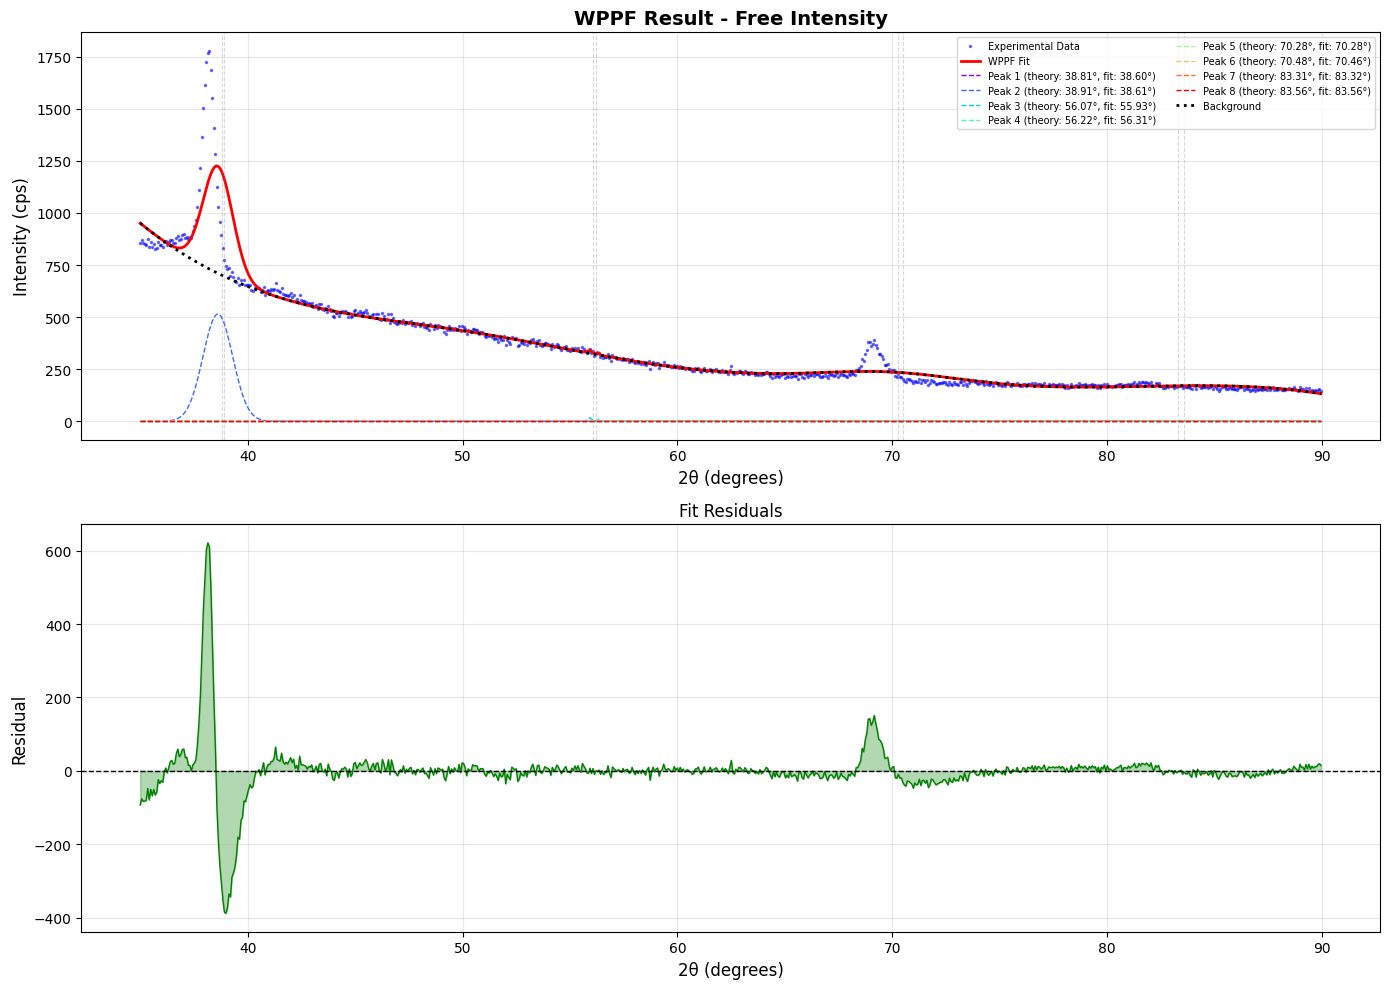


=== Fitting Statistics ===
Chi-squared: 3.9934e+06
Reduced chi-squared: 5.3675e+03
R-squared (R²): 0.915843
AIC: 6791.0945
BIC: 6987.1066

R-factors:
  Rp:     7.39%
  Rwp:    12.57%
  RBragg: 3.77%

=== Peak Parameters ===
Peak   Theory 2θ    Fitted 2θ    Δ2θ        Amplitude    FWHM      
------------------------------------------------------------------------
1      38.8136      38.5977      -0.2159    0.00         0.0204    
2      38.9136      38.6136      -0.3000    887.41       1.6196    
3      56.0658      55.9257      -0.1400    5.25         0.2034    
4      56.2158      56.3145      0.0987     1.35         0.1001    
5      70.2775      70.2818      0.0043     0.00         0.1591    
6      70.4776      70.4598      -0.0177    0.00         0.1079    
7      83.3092      83.3157      0.0065     0.00         0.1820    
8      83.5592      83.5604      0.0012     0.00         0.1674    


C:\Users\sato1\AppData\Local\Temp\ipykernel_26068\2548928397.py:343: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_calc = np.trapz(peak_comp, x)
C:\Users\sato1\AppData\Local\Temp\ipykernel_26068\2548928397.py:353: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_obs = np.trapz(np.maximum(y[mask] - y_bg[mask], 0), x[mask])


In [21]:
# 強度比自由でWPPF実行
if peaks_df is not None:
    result_free = wppf_free_intensity(
        ras_x,
        ras_y,
        peaks_df,
        PseudoVoigtModel,
        background_type="spline",
        num_knots=10,
        peak_position_tolerance=0.3,  # ピーク位置の許容変動範囲（度）
    )

    # 結果をプロット
    plot_wppf_result(ras_x, ras_y, result_free, peaks_df, method="free")

## 結果比較

2つのWPPF手法の統計値を比較して、どちらがより良いフィッティングかを評価します。

In [22]:
# 2つの手法の比較
if "result_constrained" in locals() and "result_free" in locals():
    comparison_data = {
        "Method": ["Constrained Intensity", "Free Intensity"],
        "Chi-squared": [result_constrained.chisqr, result_free.chisqr],
        "Reduced χ²": [result_constrained.redchi, result_free.redchi],
        "R-squared": [result_constrained.rsquared, result_free.rsquared],
        "AIC": [result_constrained.aic, result_free.aic],
        "BIC": [result_constrained.bic, result_free.bic],
    }

    comparison_df = pl.DataFrame(comparison_data)
    print("\n=== WPPF Methods Comparison ===")
    print(comparison_df)

    # どちらが良いか判定
    print("\n=== Recommendation ===")
    if result_free.rsquared > result_constrained.rsquared:
        print("✓ Free Intensity法の方がR²値が高く、より良いフィッティングです")
    else:
        print("✓ Constrained Intensity法の方がR²値が高く、より良いフィッティングです")

    if result_free.aic < result_constrained.aic:
        print("✓ Free Intensity法の方がAICが低く、モデルの質が良いです")
    else:
        print("✓ Constrained Intensity法の方がAICが低く、モデルの質が良いです")

    print("\n注: 理論強度比と実験値が一致する場合はConstrained Intensityが有効")
    print("    優先配向や不純物がある場合はFree Intensityが適切です")


=== WPPF Methods Comparison ===
shape: (2, 6)
┌───────────────────────┬─────────────┬───────────────┬───────────┬──────────────┬─────────────┐
│ Method                ┆ Chi-squared ┆ Reduced χ²    ┆ R-squared ┆ AIC          ┆ BIC         │
│ ---                   ┆ ---         ┆ ---           ┆ ---       ┆ ---          ┆ ---         │
│ str                   ┆ f64         ┆ f64           ┆ f64       ┆ f64          ┆ f64         │
╞═══════════════════════╪═════════════╪═══════════════╪═══════════╪══════════════╪═════════════╡
│ Constrained Intensity ┆ 4.3287e8    ┆ 581810.006783 ┆ -8.122196 ┆ 10474.121005 ┆ 10670.13319 │
│ Free Intensity        ┆ 3.9934e6    ┆ 5367.485375   ┆ 0.915843  ┆ 6791.094451  ┆ 6987.106637 │
└───────────────────────┴─────────────┴───────────────┴───────────┴──────────────┴─────────────┘

=== Recommendation ===
✓ Free Intensity法の方がR²値が高く、より良いフィッティングです
✓ Free Intensity法の方がAICが低く、モデルの質が良いです

注: 理論強度比と実験値が一致する場合はConstrained Intensityが有効
    優先配向や不純物がある場合はFree Inten